# Modelado y comparación de experimentos

Este notebook compara los cuatro datasets creados en `03_feature_engineering.ipynb`.

El **test (2018–2025)** queda reservado y no se utiliza para elegir modelos.  
Toda la comparación A/B/C/D se realiza con el conjunto de **validación (2011–2017)**.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

TRAIN_END = pd.Timestamp("2010-12-01")
VAL_END = pd.Timestamp("2017-12-01")
TARGET_COLUMN = "target_precip_anomaly_t3"

print("Proyecto:", PROJECT_ROOT)

Proyecto: /home/gustavo-paredes/Documents/Developer/Yachay/enso-ml


## 1. Definir exactamente las features de cada experimento

In [2]:
LAGS = [1, 2, 3]

enso_variables = [
    "nino12",
    "nino3",
    "nino34",
    "nino4",
    "soi",
    "tni",
]

atmospheric_variables = [
    "temperature_c",
    "dewpoint_c",
    "u10_ms",
    "v10_ms",
    "surface_pressure_hpa",
]

hydrological_variables = [
    "evaporation_mm",
    "runoff_mm",
    "soil_water_1",
    "soil_water_2",
    "soil_water_3",
    "soil_water_4",
]

def current_and_lags(variables, lags=LAGS):
    columns = []
    for variable in variables:
        columns.append(variable)
        columns.extend(
            [f"{variable}_lag{lag}" for lag in lags]
        )
    return columns

seasonal_features = [
    "target_month_sin",
    "target_month_cos",
]

feature_columns_a = (
    current_and_lags(enso_variables)
    + seasonal_features
)

feature_columns_b = (
    feature_columns_a
    + current_and_lags(["precip_anomaly"])
)

feature_columns_c = (
    feature_columns_b
    + current_and_lags(atmospheric_variables)
)

feature_columns_d = (
    feature_columns_c
    + current_and_lags(hydrological_variables)
)

FEATURE_SETS = {
    "A_ENSO": feature_columns_a,
    "B_ENSO_PRECIP": feature_columns_b,
    "C_ENSO_PRECIP_ATMOS": feature_columns_c,
    "D_ALL": feature_columns_d,
}

for name, features in FEATURE_SETS.items():
    print(name, "->", len(features), "features")

A_ENSO -> 26 features
B_ENSO_PRECIP -> 30 features
C_ENSO_PRECIP_ATMOS -> 50 features
D_ALL -> 74 features


## 2. Cargar los cuatro datasets

In [3]:
FILES = {
    "A_ENSO": DATA_PROCESSED / "enso_precip_model_t3_a.csv",
    "B_ENSO_PRECIP": DATA_PROCESSED / "enso_precip_model_t3_b.csv",
    "C_ENSO_PRECIP_ATMOS": DATA_PROCESSED / "enso_precip_model_t3_c.csv",
    "D_ALL": DATA_PROCESSED / "enso_precip_model_t3_d.csv",
}

DATASETS = {
    name: pd.read_csv(
        path,
        parse_dates=["date", "target_date"]
    )
    for name, path in FILES.items()
}

for name, data in DATASETS.items():
    print(name, data.shape)

A_ENSO (886, 30)
B_ENSO_PRECIP (886, 34)
C_ENSO_PRECIP_ATMOS (886, 54)
D_ALL (886, 78)


In [4]:
# Verificamos que cada archivo contenga exactamente las features requeridas.
for name, features in FEATURE_SETS.items():
    missing = [
        feature
        for feature in features
        if feature not in DATASETS[name].columns
    ]
    assert not missing, f"{name} tiene features faltantes: {missing}"

print("Archivos y columnas: OK")

Archivos y columnas: OK


## 3. Split temporal

In [5]:
def temporal_split(dataframe):
    train = dataframe[
        dataframe["target_date"] <= TRAIN_END
    ].copy()

    validation = dataframe[
        dataframe["target_date"].between(
            TRAIN_END + pd.offsets.MonthBegin(1),
            VAL_END
        )
    ].copy()

    test = dataframe[
        dataframe["target_date"] > VAL_END
    ].copy()

    return train, validation, test

SPLITS = {}

for name, data in DATASETS.items():
    SPLITS[name] = temporal_split(data)

    train, val, test = SPLITS[name]

    print(
        name,
        "| Train:", len(train),
        "| Validation:", len(val),
        "| Test:", len(test)
    )

A_ENSO | Train: 710 | Validation: 84 | Test: 92
B_ENSO_PRECIP | Train: 710 | Validation: 84 | Test: 92
C_ENSO_PRECIP_ATMOS | Train: 710 | Validation: 84 | Test: 92
D_ALL | Train: 710 | Validation: 84 | Test: 92


In [6]:
# Los experimentos deben evaluar las mismas fechas objetivo.
reference_val_dates = (
    SPLITS["A_ENSO"][1]["target_date"]
    .reset_index(drop=True)
)

for name in SPLITS:
    current_val_dates = (
        SPLITS[name][1]["target_date"]
        .reset_index(drop=True)
    )
    assert current_val_dates.equals(reference_val_dates), (
        f"Las fechas de validación de {name} no coinciden con A."
    )

print("Fechas de validación A/B/C/D: iguales")

Fechas de validación A/B/C/D: iguales


## 4. Métricas y baselines

In [7]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

# Usamos A como referencia porque el target y las fechas son los mismos.
_, reference_val, _ = SPLITS["A_ENSO"]
y_val_reference = reference_val[TARGET_COLUMN]

climatology_pred = np.zeros(
    len(y_val_reference)
)

climatology_metrics = regression_metrics(
    y_val_reference,
    climatology_pred
)

# Persistencia: la anomalía futura se aproxima con la anomalía actual.
persistence_metrics = regression_metrics(
    y_val_reference,
    reference_val["precip_anomaly"]
)

baseline_results = pd.DataFrame([
    {
        "experiment": "BASELINE",
        "model": "Climatology",
        **climatology_metrics,
    },
    {
        "experiment": "BASELINE",
        "model": "Persistence",
        **persistence_metrics,
    },
])

baseline_results

,experiment,model,MAE,RMSE,R2
0,BASELINE,Climatology,46.139885,62.890983,-0.040931
1,BASELINE,Persistence,60.861866,82.381662,-0.786102


## 5. Modelos

In [8]:
def build_models():
    return {
        "Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        ),
    }

## 6. Ejecutar un experimento

La misma función se utiliza para A, B, C y D. De esta manera evitamos copiar y pegar bloques de entrenamiento y reducimos el riesgo de entrenar accidentalmente con las features de otro experimento.

In [9]:
def run_experiment(experiment_name):
    data = DATASETS[experiment_name]
    features = FEATURE_SETS[experiment_name]
    train, val, test = SPLITS[experiment_name]

    X_train = train[features].copy()
    y_train = train[TARGET_COLUMN].copy()

    X_val = val[features].copy()
    y_val = val[TARGET_COLUMN].copy()

    models = build_models()
    rows = []

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        rows.append({
            "experiment": experiment_name,
            "model": model_name,
            **regression_metrics(
                y_val,
                val_pred
            ),
        })

    results = pd.DataFrame(rows)

    return {
        "results": results,
        "models": models,
        "train": train,
        "validation": val,
        "test": test,
        "features": features,
    }

## 7. Ejecutar A, B, C y D

In [10]:
EXPERIMENT_OUTPUTS = {}

for experiment_name in FEATURE_SETS:
    print("Ejecutando:", experiment_name)

    EXPERIMENT_OUTPUTS[experiment_name] = (
        run_experiment(experiment_name)
    )

print("Experimentos terminados.")

Ejecutando: A_ENSO
Ejecutando: B_ENSO_PRECIP
Ejecutando: C_ENSO_PRECIP_ATMOS
Ejecutando: D_ALL
Experimentos terminados.


## 8. Tabla general de validación

In [11]:
model_results = pd.concat(
    [
        output["results"]
        for output in EXPERIMENT_OUTPUTS.values()
    ],
    ignore_index=True
)

all_results = pd.concat(
    [
        baseline_results,
        model_results,
    ],
    ignore_index=True
)

all_results.sort_values(
    ["RMSE", "MAE"]
).reset_index(drop=True)

,experiment,model,MAE,RMSE,R2
0,A_ENSO,Linear Regression,48.696888,62.532897,-0.029111
1,A_ENSO,Ridge,48.629304,62.810039,-0.038253
2,BASELINE,Climatology,46.139885,62.890983,-0.040931
3,B_ENSO_PRECIP,Linear Regression,46.814849,63.673649,-0.067000
4,B_ENSO_PRECIP,Ridge,47.002368,64.089917,-0.080997
5,C_ENSO_PRECIP_ATMOS,Linear Regression,49.165699,64.798734,-0.105040
6,C_ENSO_PRECIP_ATMOS,Ridge,49.024426,65.162138,-0.117470
7,D_ALL,Ridge,49.476550,66.073397,-0.148943
8,D_ALL,Linear Regression,50.429631,66.967020,-0.180231
9,B_ENSO_PRECIP,Gradient Boosting,55.738797,76.345862,-0.533967


### Mejor modelo aprendido dentro de cada experimento

Esto permite ver si agregar precipitación, atmósfera o hidrología realmente aporta capacidad predictiva.

In [12]:
best_by_experiment = (
    model_results
    .sort_values("RMSE")
    .groupby("experiment", as_index=False)
    .first()
    .sort_values("RMSE")
    .reset_index(drop=True)
)

best_by_experiment

,experiment,model,MAE,RMSE,R2
0,A_ENSO,Linear Regression,48.696888,62.532897,-0.029111
1,B_ENSO_PRECIP,Linear Regression,46.814849,63.673649,-0.067000
2,C_ENSO_PRECIP_ATMOS,Linear Regression,49.165699,64.798734,-0.105040
3,D_ALL,Ridge,49.476550,66.073397,-0.148943


## 9. Comparación visual del mejor modelo de cada experimento

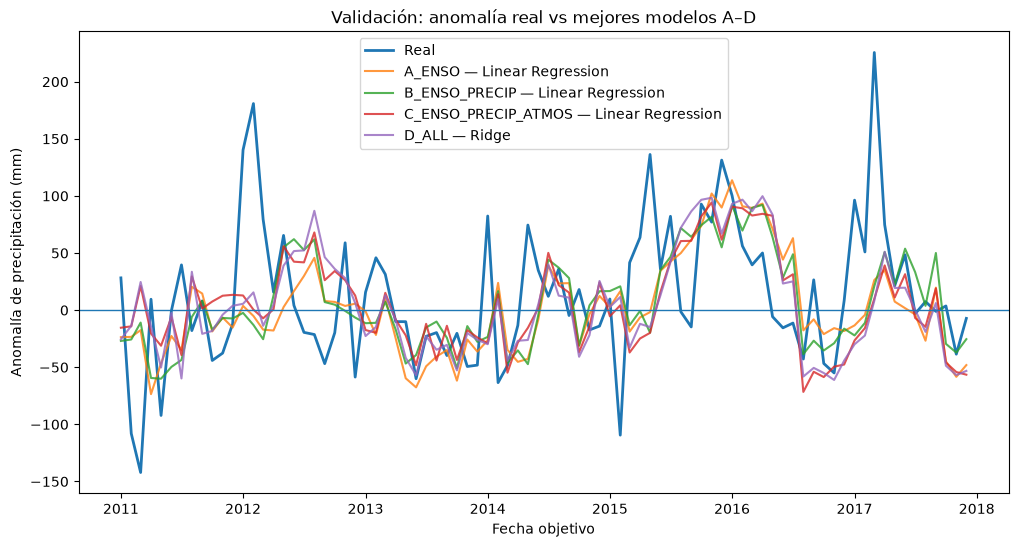

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

# Serie real común a todos los experimentos
val_reference = EXPERIMENT_OUTPUTS["A_ENSO"]["validation"]

ax.plot(
    val_reference["target_date"],
    val_reference[TARGET_COLUMN],
    label="Real",
    linewidth=2,
)

for experiment_name, output in EXPERIMENT_OUTPUTS.items():
    results = output["results"]

    best_model_name = (
        results
        .sort_values("RMSE")
        .iloc[0]["model"]
    )

    model = output["models"][best_model_name]
    val = output["validation"]
    features = output["features"]

    pred = model.predict(
        val[features]
    )

    ax.plot(
        val["target_date"],
        pred,
        label=f"{experiment_name} — {best_model_name}",
        alpha=0.8,
    )

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Validación: anomalía real vs mejores modelos A–D"
)
ax.set_xlabel("Fecha objetivo")
ax.set_ylabel("Anomalía de precipitación (mm)")
ax.legend()

plt.show()

## 10. Guardar resultados

Todavía **no evaluamos el test**. Primero interpretamos la tabla de validación y decidimos si algún experimento justifica optimización adicional o un cambio en la formulación del target.

In [14]:
RESULTS_FILE = (
    DATA_PROCESSED
    / "validation_results_experiments_a_to_d.csv"
)

all_results.to_csv(
    RESULTS_FILE,
    index=False
)

print("Guardado:", RESULTS_FILE)

Guardado: /home/gustavo-paredes/Documents/Developer/Yachay/enso-ml/data/processed/validation_results_experiments_a_to_d.csv
